In [1]:
import scipy as sp
from scipy.special import jv, hankel1, hankel2, yv, yvp, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, einsum
from utils import hl1_prime, hl2_prime, h_z_cpa_numerator, h_z_cpa, e_z_cpa, h_z_recursive_cpa, e_z_recursive_cpa
from matplotlib.pyplot import imshow
import matplotlib.cm as cm
from matplotlib.pyplot import contourf
from refractiveindex import RefractiveIndexMaterial

In [2]:
M = 1000
epsilon = 1
x = linspace(0.001, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [3]:
l = 1
j_y = jv(l, y); j_x = jv(l, x);

y_x = yv(l, x); 

j_yprime = jvp(l, y);
j_xprime = jvp(l, x);

y_xprime = yvp(l, x)

prefac = 1/(j_yprime*(j_xprime**2+y_xprime**2))
mat = np.array([[y_xprime, j_xprime], [-j_xprime, y_xprime]])
vec = np.array([j_x*j_yprime-m*j_xprime*j_y, m*j_y*y_xprime-y_x*j_yprime])

sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
sigma_real_closed_form = sigmas[0, :]
sigma_imaginary_closed_form = sigmas[1, :]
quasistatic_dispersion = (1+epsilon)*x/l

In [4]:
s_sqrds = abs(h_z_cpa(l, x, epsilon, -1j*(sigmas[0, :] + 1j*sigmas[1, :])))**2
tm_numerator = abs(h_z_cpa_numerator(l, x, epsilon, -1j*(sigmas[0, :] + 1j*sigmas[1, :])))
print("Maximum value for |s|^2: ", s_sqrds.max())
print("Maximum (absolute) value for the cpa numerator", tm_numerator.max())

Maximum value for |s|^2:  1.4444207119759304e-20
Maximum (absolute) value for the cpa numerator 1.2018440213919015e-13


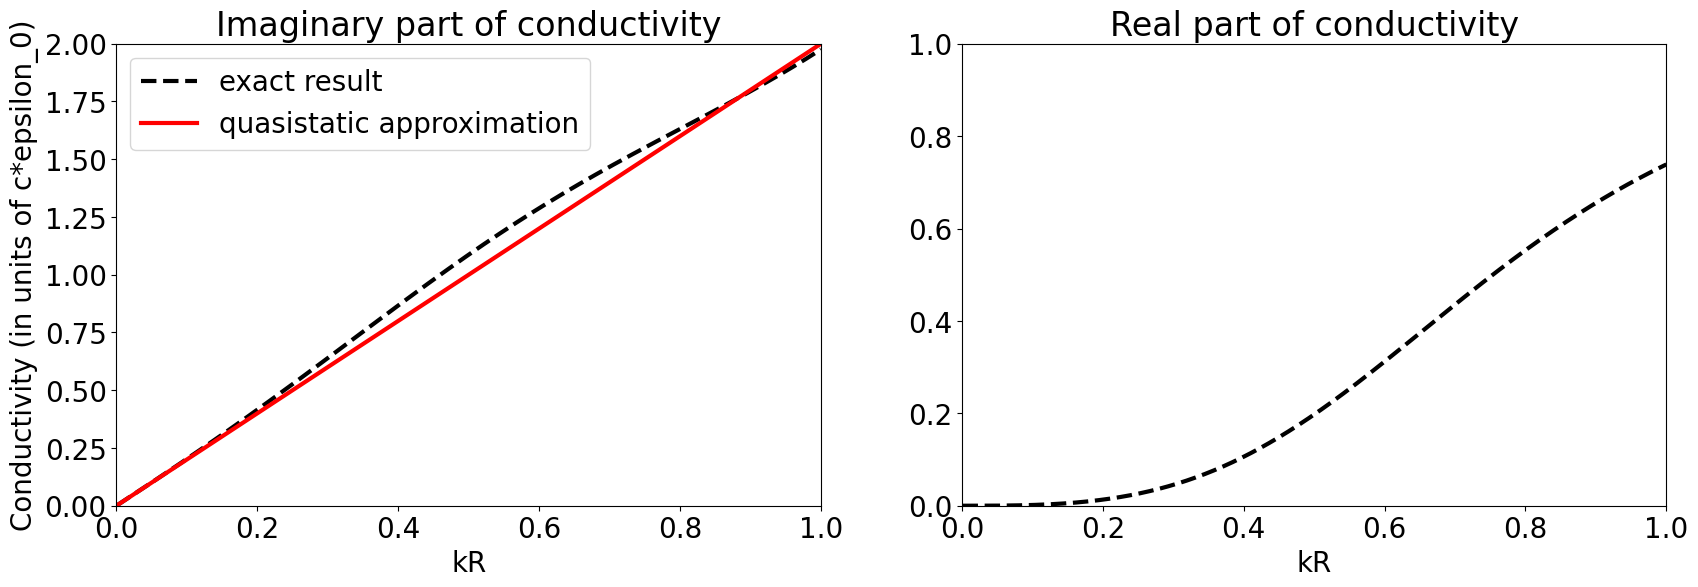

In [5]:
plt.rcParams.update({'font.size': 20})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
ax1.plot(x, sigma_imaginary_closed_form, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.plot(x, quasistatic_dispersion, label="quasistatic approximation", color="red", linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
ax1.set_xlim(0, 1)
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.legend();
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 2)
ax2.plot(x, sigma_real_closed_form, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 1)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");

In [26]:
N, M, K = 300, 300, 20
l = 1
kRs = linspace(0.02, 1, K)
kd_ratios = [0.05, 0.15, 0.45]
scattering_amplitudes_v_v = []
epsilon1 = np.ones((N, M)) 
epsilon2 = np.ones((N, M)) 
sigma_real = linspace(0, 1, N).reshape((N, 1)).repeat(M, axis=1)
sigma_imaginary = linspace(0, 3, M).reshape((1, M)).repeat(N, axis=0)

In [27]:
for (kd_ratio_idx, kd_ratio) in enumerate(kd_ratios):
    kds = kd_ratio*kRs
    scattering_amplitudes_v = []
    
    for (kR_idx, (kR, kd)) in enumerate(zip(kRs, kds)):
        if kR_idx % 25 == 0:
            print("kR_idx: ", kR_idx); 
        previous_coefficients = np.array([1, 1])
        
        epsilon_thin_film = 1 + 1j*(sigma_real + 1j*sigma_imaginary)/(kd)
        next_coefficients = h_z_recursive_cpa(previous_coefficients, l, epsilon1, epsilon_thin_film, (kR-kd/2)*ones((N, M)))
        
        # The dielectric constant will be depend on the thickness: epsilon = 1+ i*sigma/(omega*epsilon_0*d)
        # If we write this in terms of normalized conductivities, simga_primes, (in units of c*epsilon_0), we obtain
        # epsilon = 1+ i*sigma_prime/(omega*d/c) = 1+ i*sigma_prime/(k*d)
        # Therefore, the only free parameters are the unitless quantities, kR and kd. 
        
        next_coefficients = h_z_recursive_cpa(next_coefficients, l, epsilon_thin_film, epsilon2, (kR+kd/2)*ones((N, M)))
        
        scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
        scattering_amplitudes_v.append(scattering_amplitudes)
    scattering_amplitudes_v_v.append(scattering_amplitudes_v)


kR_idx:  0
kR_idx:  0
kR_idx:  0


In [28]:
argmin_indices = [[scattering_amplitudes_v[idx].argmin() for idx in range(0, K)] for scattering_amplitudes_v in scattering_amplitudes_v_v]
flattened_sigma_real = sigma_real.flatten() 
flattened_sigma_imaginary = sigma_imaginary.flatten()

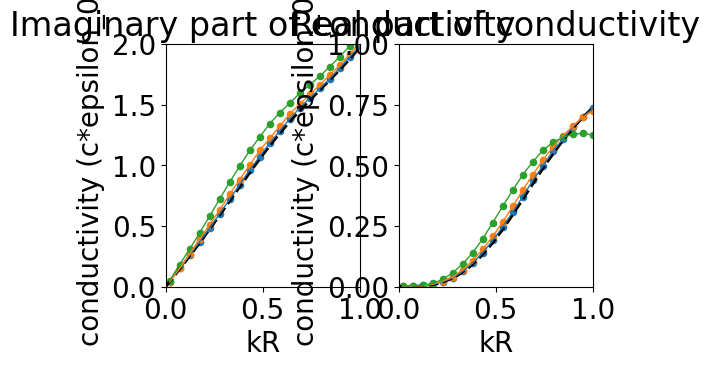

In [42]:
cm = 1/2.54

plt.rcParams.update({'font.size': 20})
s=20
linewidth=2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14*cm, 8*cm))
ax1.plot(x, sigma_imaginary_closed_form, color="black", label="Closed form solution for d=0", linewidth=linewidth, linestyle="dashed")
ax2.plot(x, sigma_real_closed_form, color="black", label="Closed form solution for d=0", linewidth=linewidth, linestyle="dashed")

for (kd_ratio_idx, kd_ratio) in enumerate(kd_ratios):
    ax1.scatter(kRs, flattened_sigma_imaginary[argmin_indices[kd_ratio_idx]], linewidth=1, label=f"d/r={kd_ratio}", s=s)
    ax2.scatter(kRs, flattened_sigma_real[argmin_indices[kd_ratio_idx]], linewidth=1, label=f"d/r={kd_ratio}", s=s)
    ax1.plot(kRs, flattened_sigma_imaginary[argmin_indices[kd_ratio_idx]], linewidth=1, label=f"d/r={kd_ratio}")
    ax2.plot(kRs, flattened_sigma_real[argmin_indices[kd_ratio_idx]], linewidth=1, label=f"d/r={kd_ratio}")

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 2)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1);
ax1.set_xlabel("kR")
ax2.set_xlabel("kR")
ax1.set_ylabel("conductivity (c*epsilon_0)")
ax2.set_ylabel("conductivity (c*epsilon_0)")
#ax1.legend()
#ax2.legend();
ax1.set_title("Imaginary part of conductivity")
ax2.set_title("Real part of conductivity");
plt.savefig("./paper/thin_film_limit_tm.pdf");

# Now we look at the magnetic modes, expecting a similar convergence to the closed form solution in the limit $d\rightarrow 0$

In [20]:
M = 1000
epsilon = 1
x_1 = 0.5
x_2 = 1
x = linspace(x_1, x_2, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [33]:
l = 1
j_y = jv(l, y); j_x = jv(l, x);

y_x = yv(l, x); 

j_yprime = jvp(l, y);
j_xprime = jvp(l, x);

y_xprime = yvp(l, x)

prefac = 1/(j_y*(j_x**2+y_x**2))
mat = np.array([[y_x, j_x], [-j_x, y_x]])
vec = np.array([m*j_x*j_yprime-j_xprime*j_y, j_y*y_xprime-m*y_x*j_yprime])
sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
sigma_real_closed_form = sigmas[0, :]
sigma_imaginary_closed_form = sigmas[1, :]
small_cylinder_dispersion = -(2*l)/x

In [22]:
s_sqrds = abs(e_z_cpa(l, x, 1, -1j*(sigmas[0, :] + 1j*sigmas[1, :])))**2
print("Maximum value for |s|^2: ", s_sqrds.max())

Maximum value for |s|^2:  2.429926226966748e-30


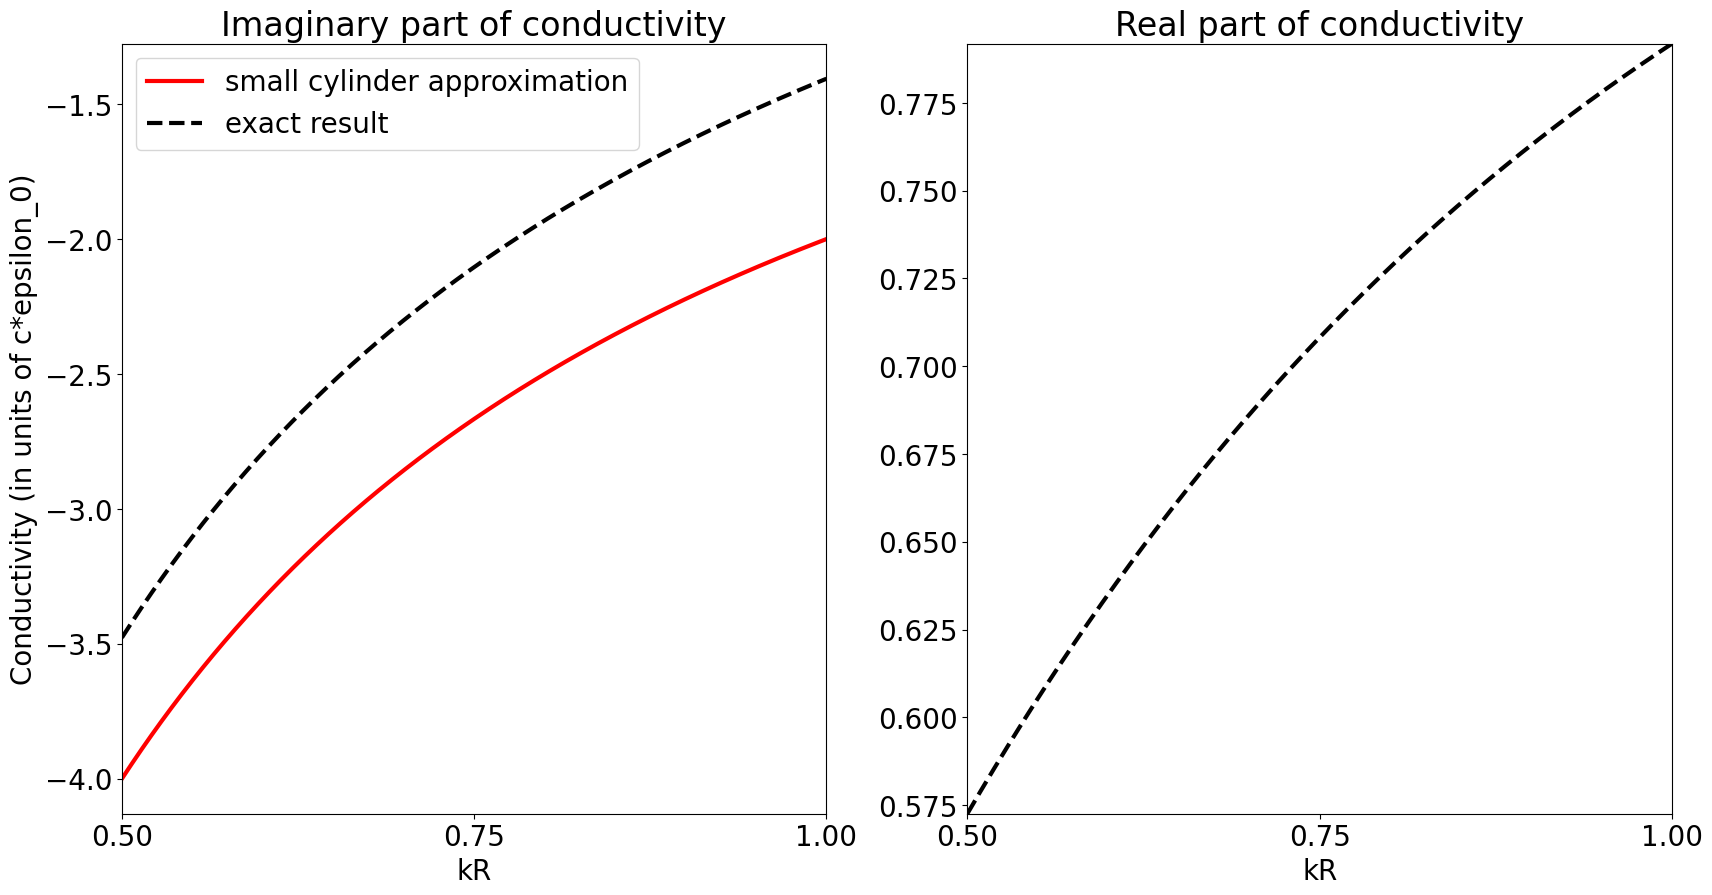

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.plot(x, small_cylinder_dispersion, label="small cylinder approximation", color="red", linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
ax1.plot(x, sigma_imaginary, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.set_xlim(x_1, x_2)
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.set_xticks([x_1, (x_1+x_2)/2, x_2])
ax1.legend();

ax2.plot(x, sigma_real, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.set_xlim(x_1, x_2)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");
ax2.set_xticks([x_1, (x_1+x_2)/2, x_2]);
ax2.set_ylim(sigma_real.min(), sigma_real.max());

In [36]:
N, M, K = 200, 200, 100
l = 1
kRs = linspace(0.02, 1, K)
kd_ratios = [0.01, 0.1, 0.2, 0.3]
scattering_amplitudes_v_v = []
epsilon1 = np.ones((N, M)) # Take a fixed dielectric constant for silica 
epsilon2 = np.ones((N, M)) 
sigma_real = linspace(0, 1, N).reshape((N, 1)).repeat(M, axis=1)
sigma_imaginary = linspace(-5, 0, M).reshape((1, M)).repeat(N, axis=0)

In [37]:
for (kd_ratio_idx, kd_ratio) in enumerate(kd_ratios):
    kds = kd_ratio*kRs
    scattering_amplitudes_v = []
    
    for (kR_idx, (kR, kd)) in enumerate(zip(kRs, kds)):
        if kR_idx % 25 == 0:
            print("kR_idx: ", kR_idx); 
        previous_coefficients = np.array([1, 1])
        
        epsilon_thin_film = 1 + 1j*(sigma_real + 1j*sigma_imaginary)/(kd)
        next_coefficients = e_z_recursive_cpa(previous_coefficients, l, epsilon1, epsilon_thin_film, (kR-kd/2)*ones((N, M)))
        
        # The dielectric constant will be depend on the thickness: epsilon = 1+ i*sigma/(omega*epsilon_0*d)
        # If we write this in terms of normalized conductivities, simga_primes, (in units of c*epsilon_0), we obtain
        # epsilon = 1+ i*sigma_prime/(omega*d/c) = 1+ i*sigma_prime/(k*d)
        # Therefore, the only free parameters are the unitless quantities, kR and kd. 
        
        next_coefficients = e_z_recursive_cpa(next_coefficients, l, epsilon_thin_film, epsilon2, (kR+kd/2)*ones((N, M)))
        
        scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
        scattering_amplitudes_v.append(scattering_amplitudes)
    scattering_amplitudes_v_v.append(scattering_amplitudes_v)


kR_idx:  0
kR_idx:  25
kR_idx:  50
kR_idx:  75
kR_idx:  0
kR_idx:  25
kR_idx:  50
kR_idx:  75
kR_idx:  0
kR_idx:  25
kR_idx:  50
kR_idx:  75
kR_idx:  0
kR_idx:  25
kR_idx:  50
kR_idx:  75


In [38]:
argmin_indices = [[scattering_amplitudes_v[idx].argmin() for idx in range(0, K)] for scattering_amplitudes_v in scattering_amplitudes_v_v]
flattened_sigma_real = sigma_real.flatten()
flattened_sigma_imaginary = sigma_imaginary.flatten()

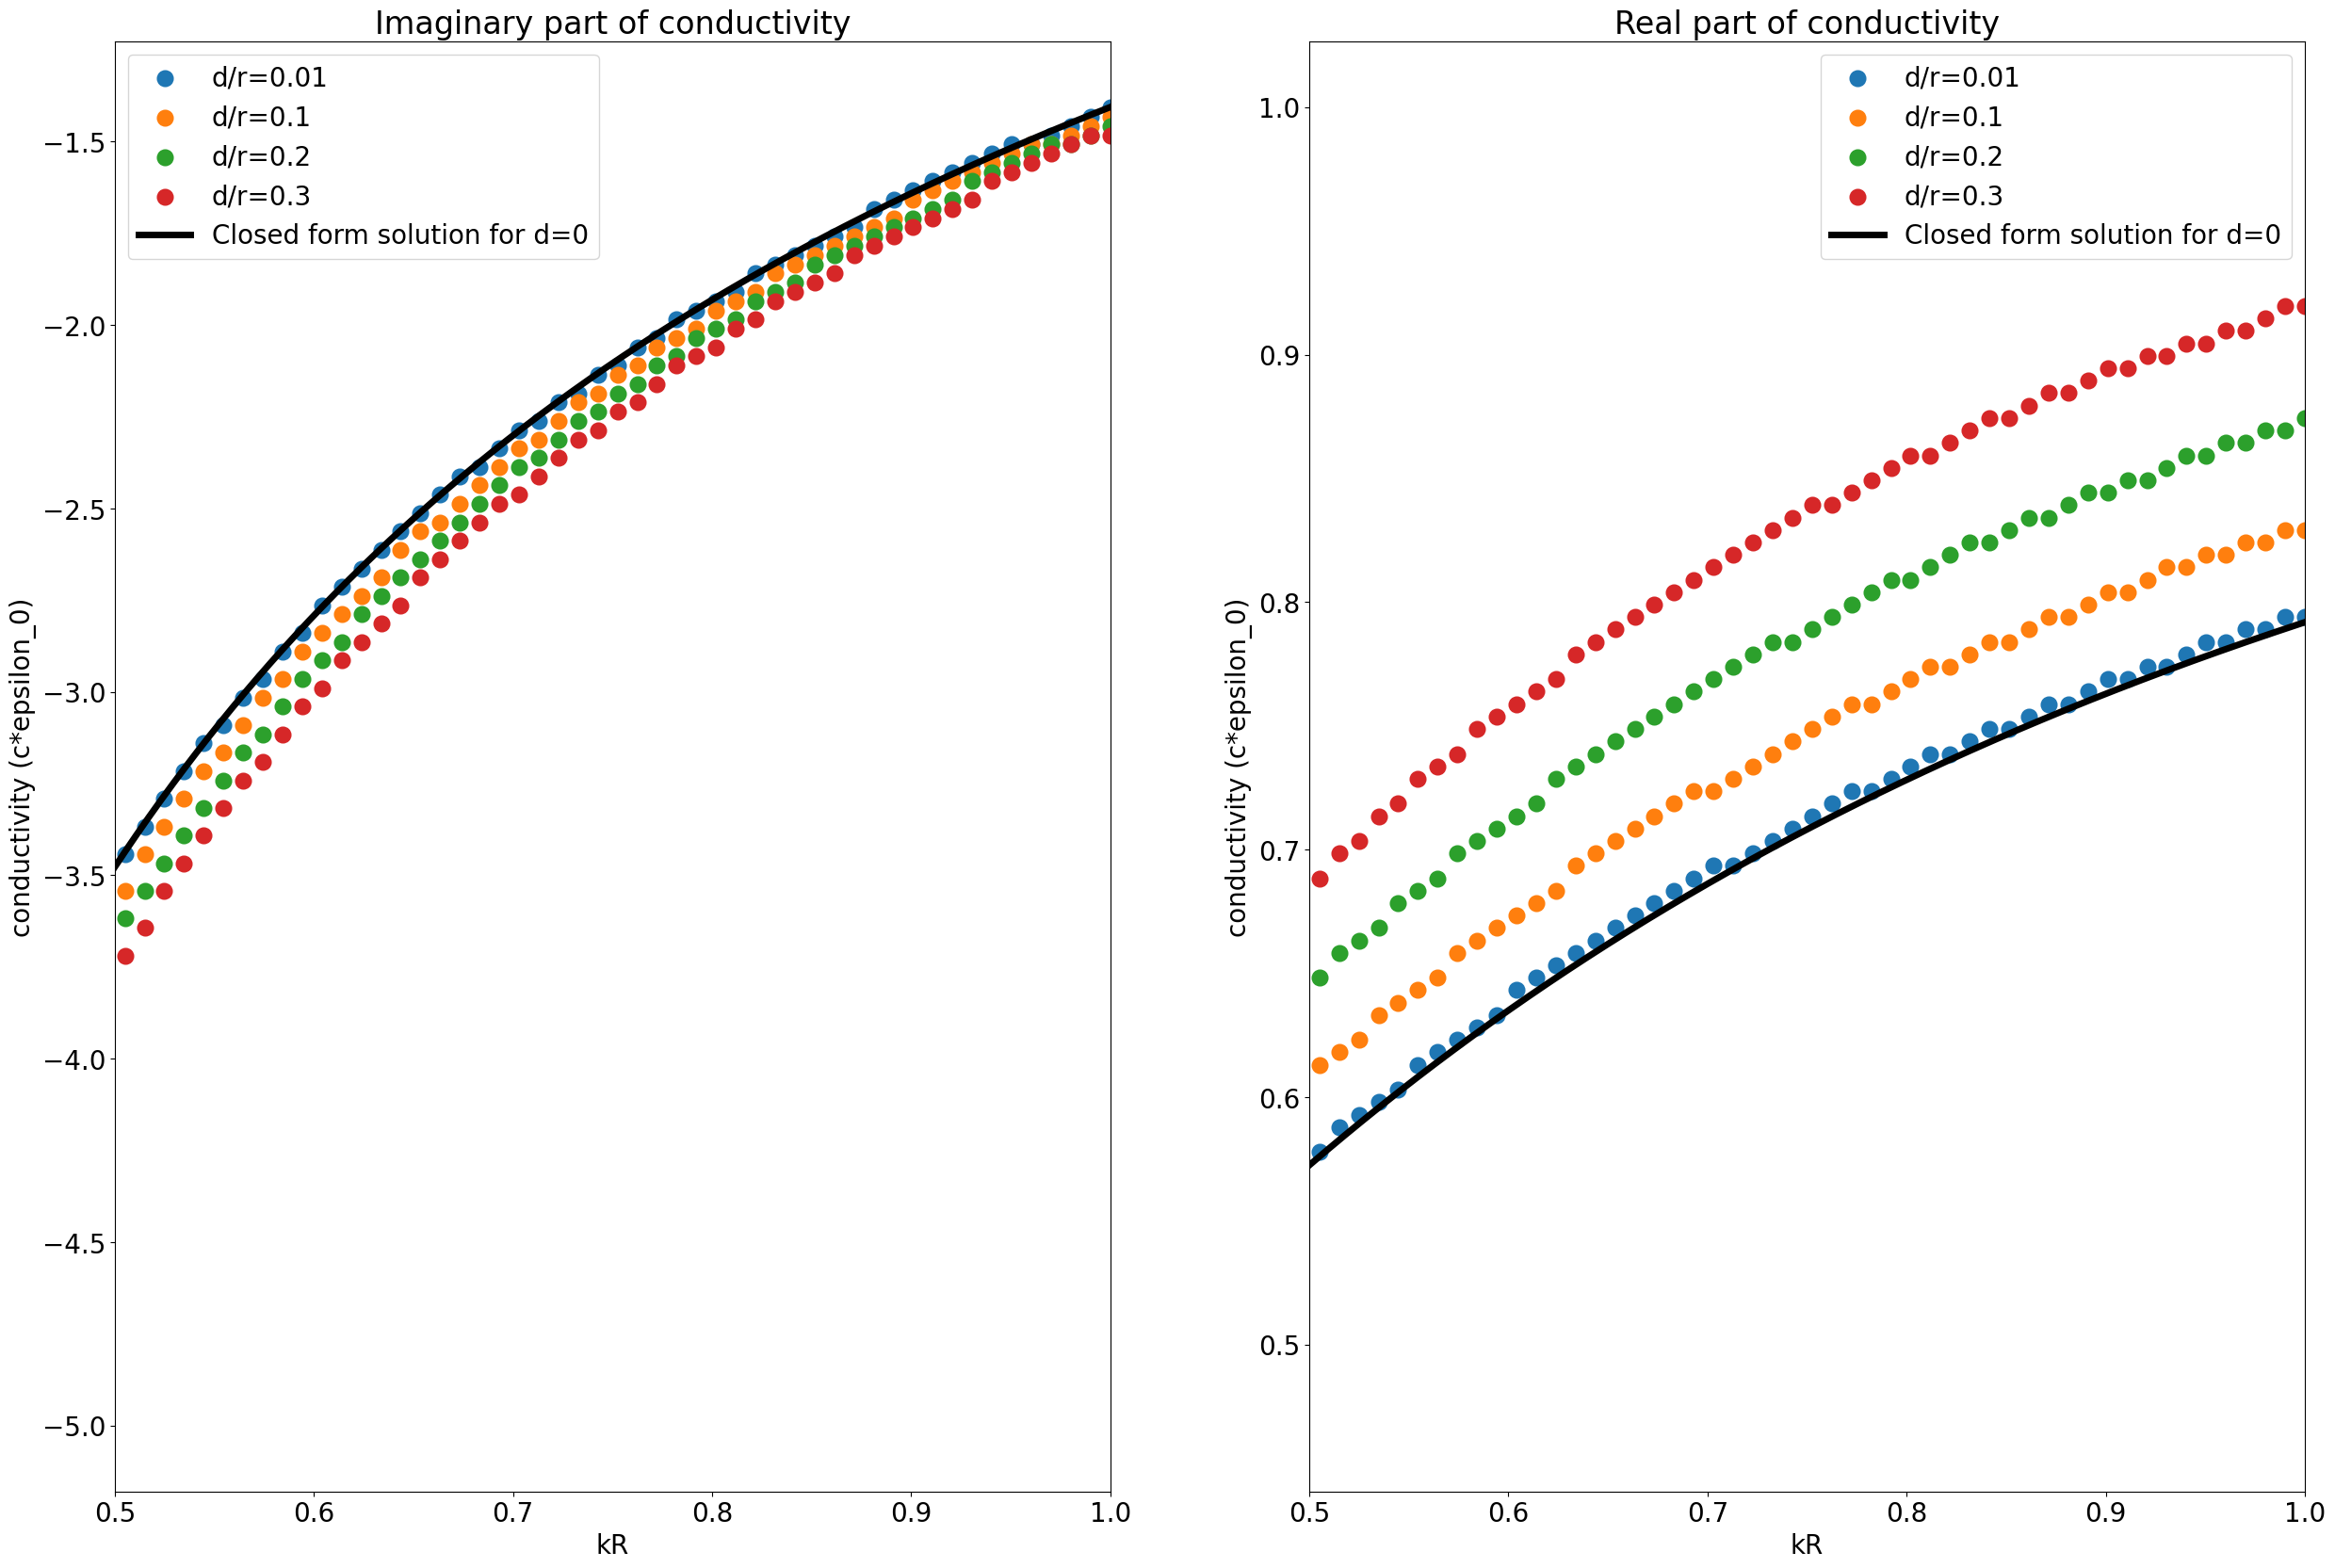

In [39]:
plt.rcParams.update({'font.size': 20})
s=100
linewidth=5
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 20))
for (kd_ratio_idx, kd_ratio) in enumerate(kd_ratios):
    ax1.scatter(kRs, flattened_sigma_imaginary[argmin_indices[kd_ratio_idx]], linewidth=3, label=f"d/r={kd_ratio}", s=s)
    ax2.scatter(kRs, flattened_sigma_real[argmin_indices[kd_ratio_idx]], linewidth=3, label=f"d/r={kd_ratio}", s=s)
ax1.plot(x, sigma_imaginary_closed_form, color="black", label="Closed form solution for d=0", linewidth=linewidth)
ax2.plot(x, sigma_real_closed_form, color="black", label="Closed form solution for d=0", linewidth=linewidth)
ax1.set_xlim(x_1, x_2)
#ax1.set_ylim(0, 2)
ax2.set_xlim(0, 1)
ax2.set_xlim(x_1, x_2)
ax1.set_xlabel("kR")
ax2.set_xlabel("kR")
ax1.set_ylabel("conductivity (c*epsilon_0)")
ax2.set_ylabel("conductivity (c*epsilon_0)")
ax1.legend()
ax2.legend();
ax1.set_title("Imaginary part of conductivity")
ax2.set_title("Real part of conductivity");

# In analogy with **Figure 3** of [Perfect coupling of light to surface plasmons by coherent absorption](https://journals.aps.org/prl/pdf/10.1103/PhysRevLett.108.186805), we compute the CPA condition for a multilayer with a Silica core and a Cesium shell. Note that in the below, we are able to achieve CPA for an arbitrarily small core, in contrast to the case where we have a Gold shell. 

In [65]:
Silica = RefractiveIndexMaterial(shelf='main', book='SiO2', page='Franta')
Gold = RefractiveIndexMaterial(shelf='main', book='Au', page='Johnson')
Silver = RefractiveIndexMaterial(shelf='main', book='Ag', page='Johnson')
Platinum = RefractiveIndexMaterial(shelf='main', book='Pt', page='Werner')
Copper = RefractiveIndexMaterial(shelf='main', book='Cu', page='Johnson')
Aluminum = RefractiveIndexMaterial(shelf='main', book='Al', page='Rakic')
Cesium = RefractiveIndexMaterial(shelf='main', book='Cs', page='Smith')

wavelengths_nm = linspace(400, 1500, 301)  # [nm]

silica_epsilon = Silica.get_epsilon(wavelengths_nm)
gold_epsilon = Gold.get_epsilon(wavelengths_nm)
silver_epsilon = Silver.get_epsilon(wavelengths_nm)
platinum_epsilon = Platinum.get_epsilon(wavelengths_nm)
copper_epsilon = Copper.get_epsilon(wavelengths_nm)
aluminum_epsilon = Aluminum.get_epsilon(wavelengths_nm)
cesium_epsilon = Cesium.get_epsilon(wavelengths_nm)

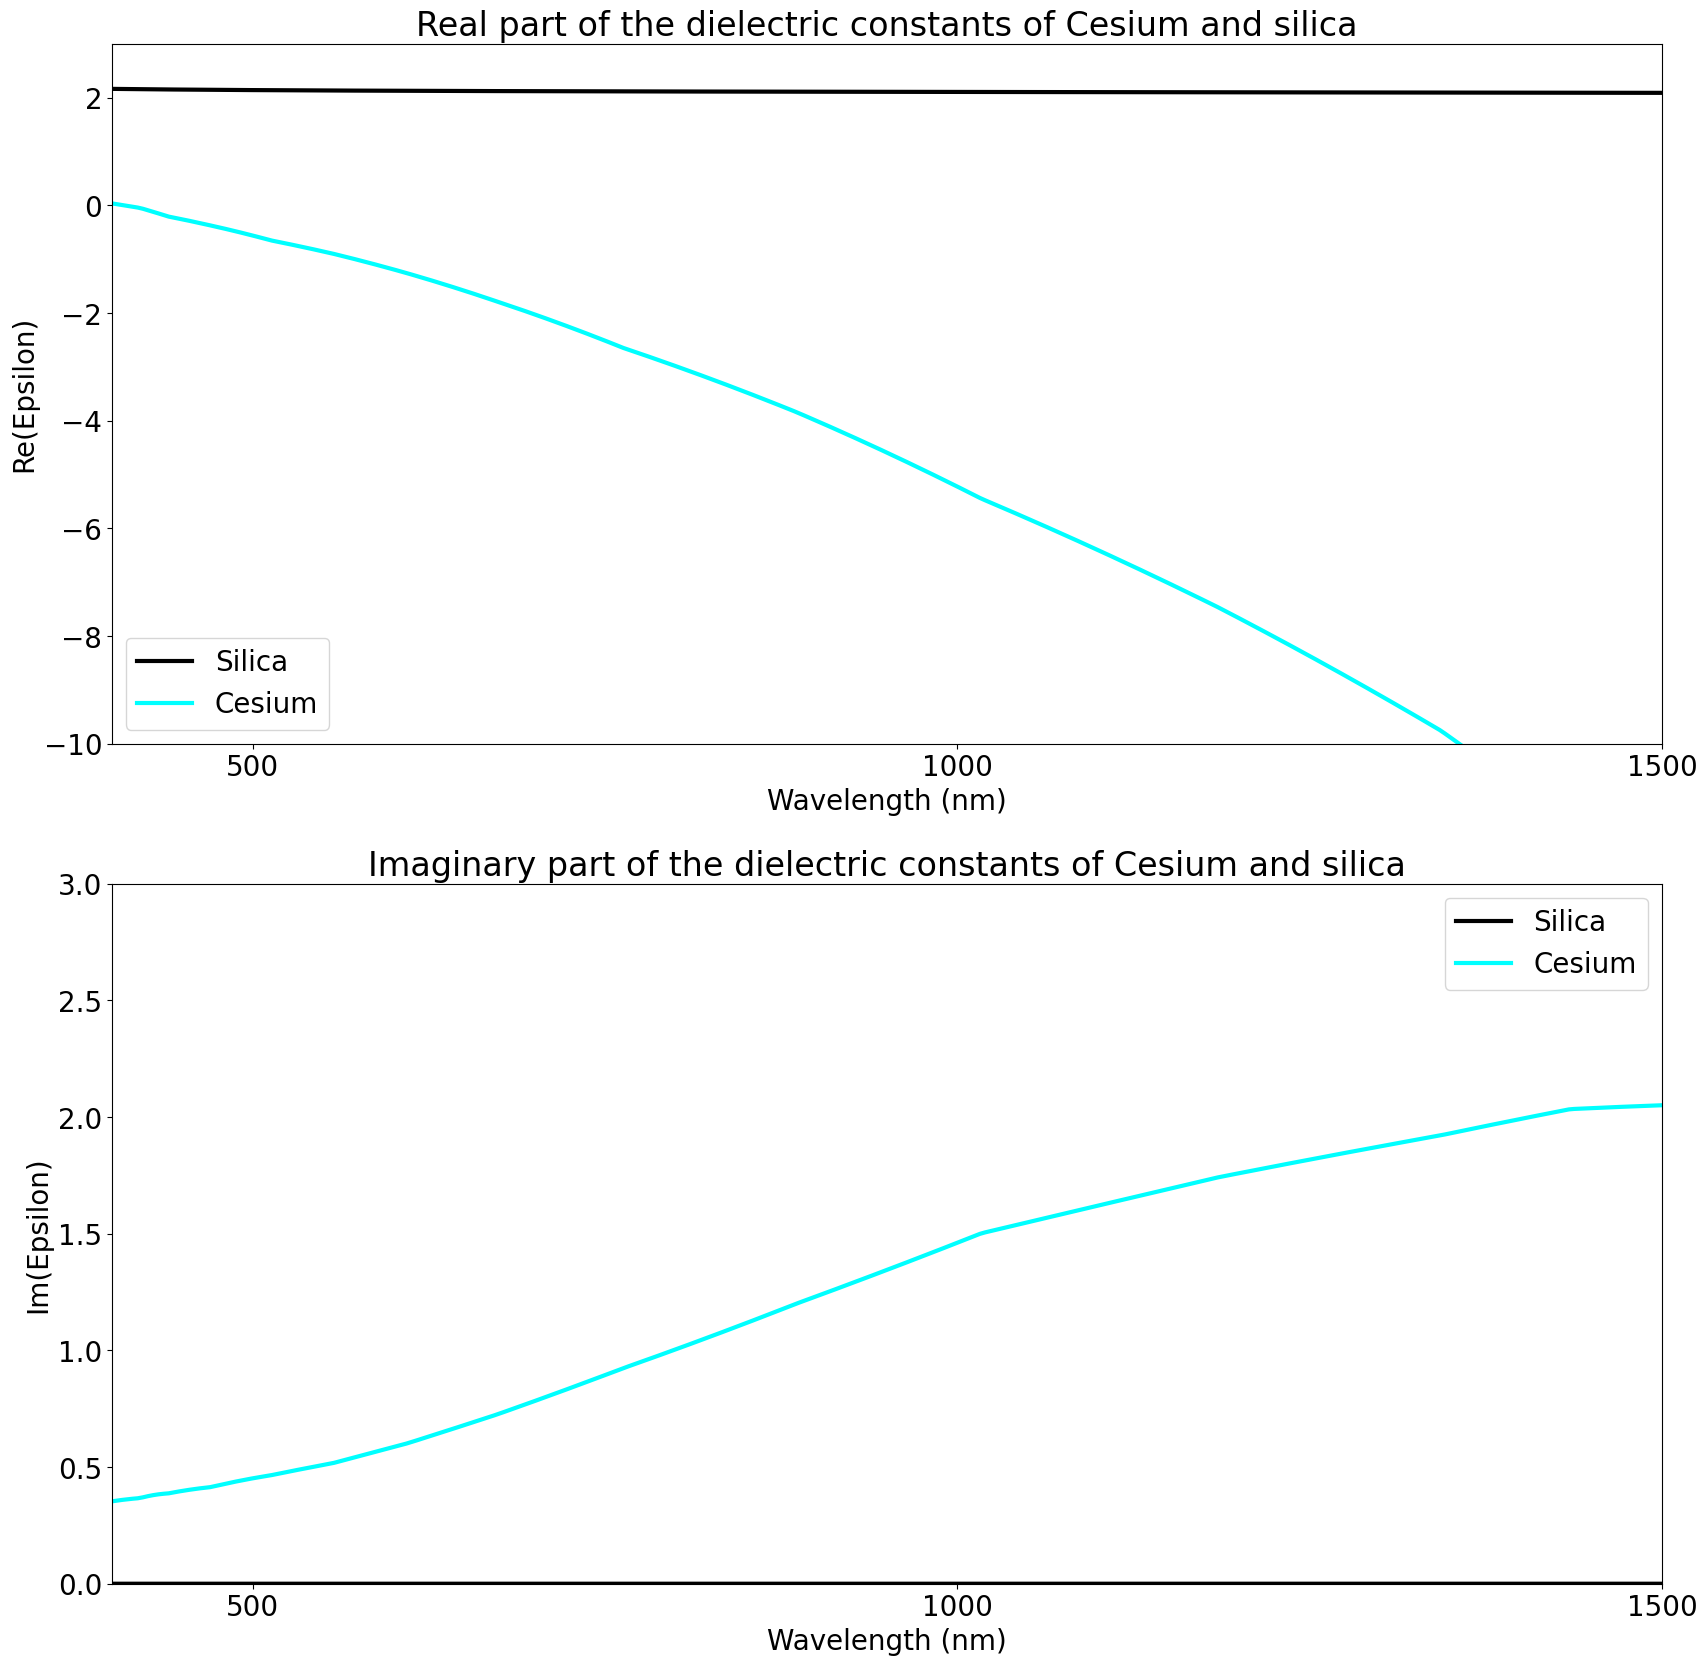

In [66]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))
linewidth=3
ax1.plot(wavelengths_nm, silica_epsilon.real, color="black", label="Silica", linewidth=linewidth)
#ax1.plot(wavelengths_nm, silver_epsilon.real, color="green", label="Silver", linewidth=linewidth)
#ax1.plot(wavelengths_nm, gold_epsilon.real, color="red", label="Gold", linewidth=linewidth)
#ax1.plot(wavelengths_nm, platinum_epsilon.real, color="orange", label="Platinum", linewidth=linewidth)
#ax1.plot(wavelengths_nm, copper_epsilon.real, color="blue", label="Copper", linewidth=linewidth)
#ax1.plot(wavelengths_nm, aluminum_epsilon.real, color="purple", label="Aluminum", linewidth=linewidth)
ax1.plot(wavelengths_nm, cesium_epsilon.real, color="cyan", label="Cesium", linewidth=linewidth)

ax1.set_xlim(400, 1500);
ax1.set_xticks([500, 1000, 1500])
ax1.set_ylim(-10, 3)
ax1.set_title("Real part of the dielectric constants of Cesium and silica")
ax1.legend();
ax1.set_xlabel("Wavelength (nm)")
ax1.set_ylabel("Re(Epsilon)");

ax2.plot(wavelengths_nm, silica_epsilon.imag, color="black", label="Silica", linewidth=linewidth)
#ax1.plot(wavelengths_nm, silver_epsilon.real, color="green", label="Silver", linewidth=linewidth)
#ax1.plot(wavelengths_nm, gold_epsilon.real, color="red", label="Gold", linewidth=linewidth)
#ax1.plot(wavelengths_nm, platinum_epsilon.real, color="orange", label="Platinum", linewidth=linewidth)
#ax1.plot(wavelengths_nm, copper_epsilon.real, color="blue", label="Copper", linewidth=linewidth)
#ax1.plot(wavelengths_nm, aluminum_epsilon.real, color="purple", label="Aluminum", linewidth=linewidth)
ax2.plot(wavelengths_nm, cesium_epsilon.imag, color="cyan", label="Cesium", linewidth=linewidth)

ax2.set_xlim(400, 1500);
ax2.set_xticks([500, 1000, 1500])
ax2.set_ylim(0, 3)
ax2.set_title("Imaginary part of the dielectric constants of Cesium and silica")
ax2.legend();
ax2.set_xlabel("Wavelength (nm)")
ax2.set_ylabel("Im(Epsilon)");

In [56]:
K = 100
M = 200
N = 200
R_min = 50; R_max = 70
lambda_min = 500; lambda_max = 600
R_c_ratios = linspace(0.01, 0.4, K, endpoint=True)
Rs = linspace(R_min, R_max, N, endpoint=True)
wavelengths = linspace(lambda_min, lambda_max, M, endpoint=True)

silica_epsilon = Silica.get_epsilon(wavelengths)
cesium_epsilon = Cesium.get_epsilon(wavelengths)

best_wavelengths = array([])
best_Rs = array([])
for (i, R_c_ratio) in enumerate(R_c_ratios): 
    
    scattering_amplitudes = np.zeros((N, M))
    previous_coefficients = np.array([1, 1])
    epsilon2 = cesium_epsilon .reshape((1, M)).repeat(N, 0) ; epsilon1 = silica_epsilon.reshape((1, M)).repeat(N, 0) 
    kR = (2*pi/wavelengths).reshape((1, M)).repeat(N, 0) * Rs.reshape((N, 1)).repeat(M, 1) * R_c_ratio
    next_coefficients = h_z_recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
    
    epsilon2 = ones(N).reshape((1, M)).repeat(N, 0) ; epsilon1 = cesium_epsilon.reshape((1, M)).repeat(N, 0) 
    kR = (2*pi/wavelengths).reshape((1, M)).repeat(N, 0) * Rs.reshape((N, 1)).repeat(M, 1) 
    next_coefficients = h_z_recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
    
    scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
    idx = scattering_amplitudes.argmin()
    row, col = unravel_index(idx, epsilon2.shape)
    best_Rs = np.append(best_Rs, Rs[row])
    best_wavelengths = np.append(best_wavelengths, wavelengths[col])

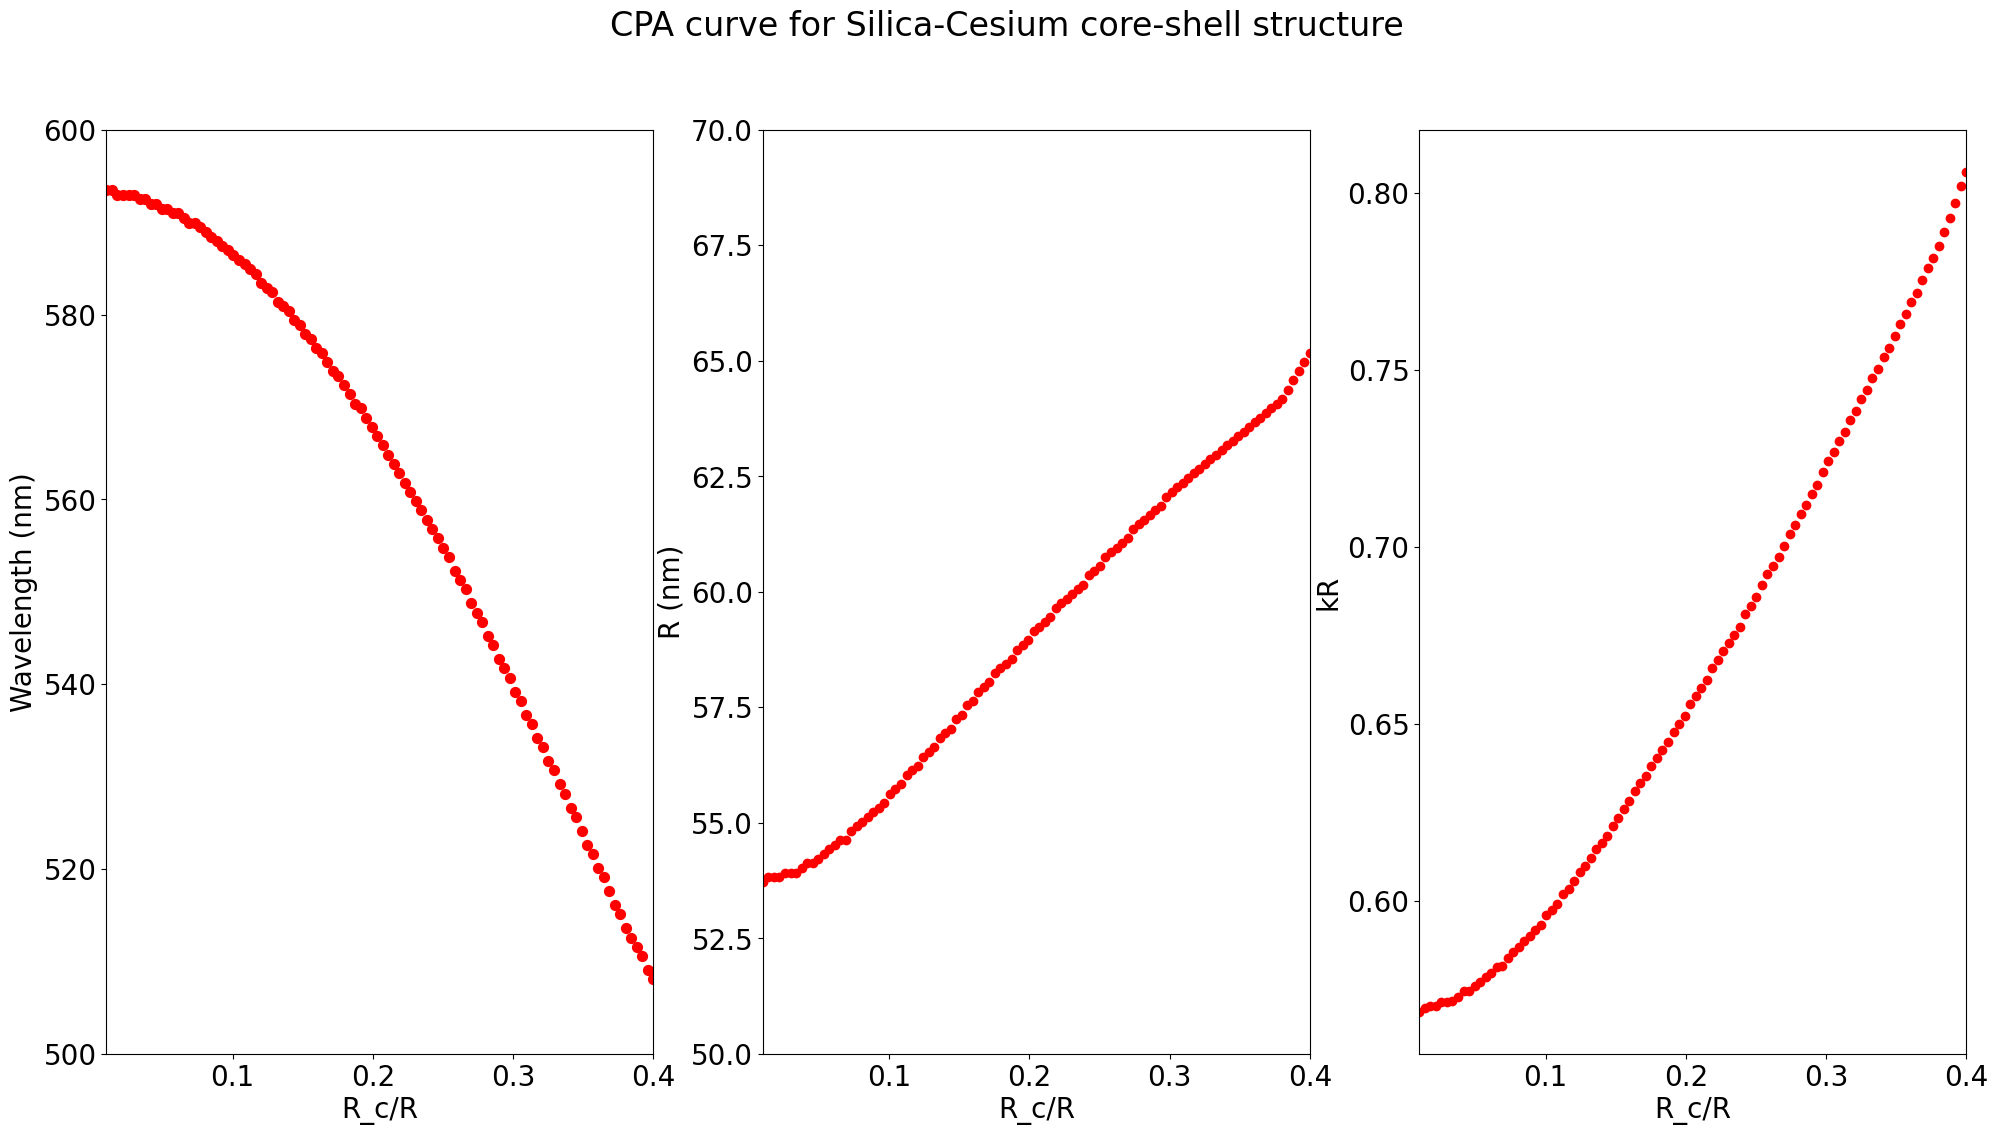

In [63]:
s = 50
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 12))
ax1.scatter(R_c_ratios, best_wavelengths, color="red", s=s)
ax2.scatter(R_c_ratios, best_Rs, color="red")
ax3.scatter(R_c_ratios, (2*pi/best_wavelengths)*best_Rs, color="red")
ax1.set_xlim(0.01, 0.4)
ax2.set_xlim(0.01, 0.4)
ax3.set_xlim(0.01, 0.4)

ax1.set_ylim(lambda_min, lambda_max)
ax2.set_ylim(R_min, R_max)
ax1.set_xlabel("R_c/R");
ax2.set_xlabel("R_c/R");
ax3.set_xlabel("R_c/R");

ax1.set_ylabel("Wavelength (nm)");
ax2.set_ylabel("R (nm)");
ax3.set_ylabel("kR");
fig.suptitle("CPA curve for Silica-Cesium core-shell structure");